# MATH/CSCI 485 — Assignment #3: Image Compression via Block-wise SVD

**Objective:** Explore Singular Value Decomposition (SVD) for compressing grayscale images. Apply block-wise SVD (8×8 blocks), retaining only the top-*k* singular values per block, and analyze how image quality and compression ratio change with *k* ∈ {1, 2, ..., 8}.

---

## Overview

SVD decomposes any matrix **A** (m×n) as:

$$A = U \Sigma V^T$$

where **U** is m×m orthogonal, **Σ** is m×n diagonal (singular values σ₁ ≥ σ₂ ≥ ... ≥ 0), and **V** is n×n orthogonal.  
A rank-*k* approximation retains only the top *k* singular values:

$$A_k = U_k \Sigma_k V_k^T$$

For image compression, we partition the image into non-overlapping 8×8 blocks and apply SVD to each block independently.

**Compression Ratio** for an 8×8 block:
$$\text{CR}(k) = \frac{64}{k \cdot (8 + 8 + 1)} = \frac{64}{17k}$$

## 1. Imports and Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
import os
import warnings
warnings.filterwarnings('ignore')

# Optional: for nicer plots
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

print('NumPy version:', np.__version__)
print('Setup complete.')

NumPy version: 2.3.3
Setup complete.


## 2. Preprocessing

We use a synthetically generated 256×256 grayscale image composed of sinusoidal patterns and Gaussian noise. This guarantees reproducibility without requiring an external image file. The same code works with any real image — simply load it with `Image.open()` and follow the same crop/resize steps.

**Key steps:**
- Load or generate the image.
- Convert to grayscale.
- Ensure both dimensions are divisible by 8 (crop if necessary).

Image shape: 512×512  |  dtype: float64  |  range: [9.0, 255.0]


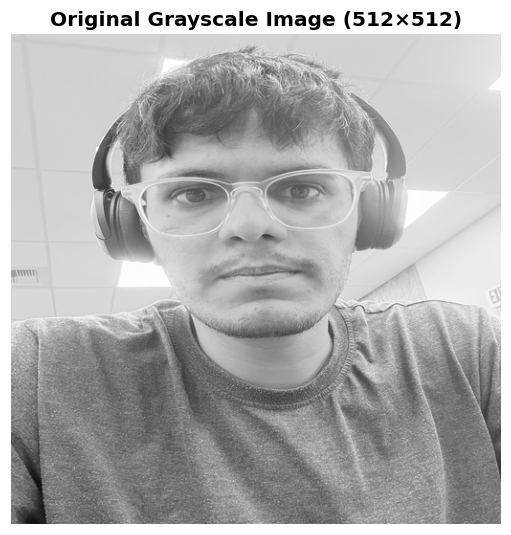

In [2]:
def load_and_preprocess(path=None, size=512, block_size=8):
    """
    Load an image from `path`, convert to grayscale,
    and crop so dimensions are divisible by block_size.
    Returns a float64 numpy array with pixel values in [0, 255].
    """
    if path:
        img = Image.open(path).convert('L')  # 'L' = 8-bit grayscale
        img = img.resize((size, size), Image.LANCZOS)
        arr = np.array(img, dtype=np.float64)
    else:
        # Fallback synthetic image
        np.random.seed(42)
        x = np.linspace(0, 4*np.pi, size); y = np.linspace(0, 4*np.pi, size)
        X, Y = np.meshgrid(x, y)
        arr = (np.sin(X)*np.cos(Y)*0.5 + np.sin(2*X)*0.3 + np.cos(3*Y)*0.2)
        arr = (arr - arr.min())/(arr.max()-arr.min())*255
        arr += np.random.randn(size, size)*10
        arr = np.clip(arr, 0, 255)
    H, W = arr.shape
    H = (H // block_size) * block_size
    W = (W // block_size) * block_size
    return arr[:H, :W].astype(np.float64)

# ── Set path to your image ────────────────────────────────────────────────────
IMAGE_PATH  = 'AdityaRaut.jpg'   # <-- change to your image filename
BLOCK_SIZE  = 8

img = load_and_preprocess(path=IMAGE_PATH, size=512, block_size=BLOCK_SIZE)
H, W = img.shape
print(f'Image shape: {H}×{W}  |  dtype: {img.dtype}  |  range: [{img.min():.1f}, {img.max():.1f}]')

plt.figure(figsize=(5, 5))
plt.imshow(img, cmap='gray', vmin=0, vmax=255)
plt.title('Original Grayscale Image (512×512)', fontweight='bold')
plt.axis('off'); plt.tight_layout(); plt.show()

## 3. Block-wise SVD Compression

### Key function: `compress_block(block, k)`

Given an 8×8 block **B**:
1. Compute the full SVD: **B** = **U** Σ **V**ᵀ
2. Truncate to top-*k* components: **U_k** (8×k), **σ_k** (k,), **V_k**ᵀ (k×8)
3. Reconstruct: **B̂_k** = **U_k** · diag(**σ_k**) · **V_k**ᵀ

The reconstructed block **B̂_k** is the best rank-*k* approximation of **B** in the Frobenius norm sense (Eckart–Young theorem).

### `compress_image_blockwise(img, k, block_size)`

Partitions the image into non-overlapping `block_size × block_size` blocks, applies `compress_block` to each, and reassembles the output image.

In [3]:
def compress_block(block, k):
    """
    Compress a 2D block using truncated SVD.
    
    Parameters
    ----------
    block : ndarray, shape (m, n)  — the image block
    k     : int — number of singular values/vectors to retain (1 ≤ k ≤ min(m,n))
    
    Returns
    -------
    reconstructed : ndarray, shape (m, n) — rank-k approximation of block
    """
    # full_matrices=False gives the 'economy' (thin) SVD: U is (m,k), s is (k,), Vt is (k,n)
    U, s, Vt = np.linalg.svd(block, full_matrices=False)
    # Retain only top-k components
    U_k  = U[:, :k]          # shape (m, k)
    s_k  = s[:k]             # shape (k,)
    Vt_k = Vt[:k, :]         # shape (k, n)
    # Reconstruct: multiply each column of U_k by the corresponding singular value
    return (U_k * s_k) @ Vt_k   # equivalent to U_k @ np.diag(s_k) @ Vt_k


def compress_image_blockwise(img, k, block_size=8):
    """
    Apply block-wise SVD compression to the entire image.
    
    Parameters
    ----------
    img        : ndarray (H, W)  — grayscale image
    k          : int — singular values to retain per block
    block_size : int — size of square blocks (default 8)
    
    Returns
    -------
    compressed : ndarray (H, W) — reconstructed image
    """
    H, W = img.shape
    compressed = np.zeros_like(img)
    for i in range(0, H, block_size):
        for j in range(0, W, block_size):
            block = img[i:i+block_size, j:j+block_size]
            compressed[i:i+block_size, j:j+block_size] = compress_block(block, k)
    return compressed


# ── Quick sanity check ────────────────────────────────────────────────────────
test_block = img[:8, :8].copy()
for k_test in [1, 4, 8]:
    rec = compress_block(test_block, k_test)
    err = np.linalg.norm(test_block - rec, 'fro')
    print(f'k={k_test}: block reconstruction error (Frobenius) = {err:.4f}')
print('k=8 should give ~0 error (full-rank, lossless).')

k=1: block reconstruction error (Frobenius) = 4.6880
k=4: block reconstruction error (Frobenius) = 0.8749
k=8: block reconstruction error (Frobenius) = 0.0000
k=8 should give ~0 error (full-rank, lossless).


## 4. Compression Metrics

### Compression Ratio
For an 8×8 block the data stored drops from 64 values (original) to `k × (8 + 8 + 1) = 17k` values (U_k, σ_k, V_k). Hence:
$$\text{CR}(k) = \frac{64}{17k}$$

### Frobenius Norm Error
$$\|A - A_k\|_F = \sqrt{\sum_{i,j}(A_{ij}-{A_k}_{ij})^2}$$

### PSNR (Peak Signal-to-Noise Ratio)
$$\text{PSNR} = 10 \log_{10}\!\left(\frac{255^2}{\text{MSE}}\right) \quad \text{(dB)}$$
Higher PSNR → better quality. PSNR > 40 dB is generally considered high quality.

In [4]:
def compression_ratio(k, block_size=8):
    """Compression ratio for block_size × block_size blocks retaining k singular values."""
    original = block_size * block_size
    retained = k * (block_size + block_size + 1)  # U:bs×k, Σ:k, Vt:k×bs
    return original / retained

def frobenius_error(original, compressed):
    """Total Frobenius norm of the difference."""
    return np.linalg.norm(original - compressed, 'fro')

def psnr(original, compressed, max_val=255.0):
    """Peak Signal-to-Noise Ratio in dB."""
    mse = np.mean((original - compressed) ** 2)
    if mse == 0:
        return float('inf')
    return 10 * np.log10(max_val**2 / mse)

print(f'{"k":>3} | {"CR":>8} | {"Values stored/block":>20} | {"Frob Error":>12} | {"PSNR (dB)":>10}')
print('-' * 65)
# We'll populate the table after running the compression loop below.

  k |       CR |  Values stored/block |   Frob Error |  PSNR (dB)
-----------------------------------------------------------------


## 5. Compression Analysis for k = 1 … 8

In [5]:
k_values          = list(range(1, BLOCK_SIZE + 1))
compression_ratios = []
frobenius_errors   = []
psnr_values        = []
compressed_images  = []

print(f'{"k":>3} | {"Comp. Ratio":>12} | {"Stored vals/blk":>16} | {"Frob. Error":>12} | {"PSNR (dB)":>10}')
print('-' * 62)

for k in k_values:
    comp = compress_image_blockwise(img, k, block_size=BLOCK_SIZE)
    comp_clipped = np.clip(comp, 0, 255)
    compressed_images.append(comp_clipped)

    cr  = compression_ratio(k, BLOCK_SIZE)
    err = frobenius_error(img, comp)
    ps  = psnr(img, comp)

    compression_ratios.append(cr)
    frobenius_errors.append(err)
    psnr_values.append(ps)

    stored = k * (BLOCK_SIZE + BLOCK_SIZE + 1)
    print(f'{k:>3} | {cr:>12.4f} | {stored:>16} | {err:>12.2f} | {ps:>10.2f}')

print()
print(f'k=8 is lossless within numerical precision (PSNR ≈ ∞). '
      f'k=1 gives the highest compression (~{compression_ratios[0]:.2f}×) at the cost of highest error.')

  k |  Comp. Ratio |  Stored vals/blk |  Frob. Error |  PSNR (dB)
--------------------------------------------------------------
  1 |       3.7647 |               17 |      4150.98 |      29.95
  2 |       1.8824 |               34 |      2712.28 |      33.65
  3 |       1.2549 |               51 |      1808.31 |      37.17
  4 |       0.9412 |               68 |      1170.29 |      40.95
  5 |       0.7529 |               85 |       700.29 |      45.41
  6 |       0.6275 |              102 |       362.07 |      51.14
  7 |       0.5378 |              119 |       124.10 |      60.44
  8 |       0.4706 |              136 |         0.00 |     295.35

k=8 is lossless within numerical precision (PSNR ≈ ∞). k=1 gives the highest compression (~3.76×) at the cost of highest error.


## 6. Visualization

### 6.1 Reconstructed Images for Each k

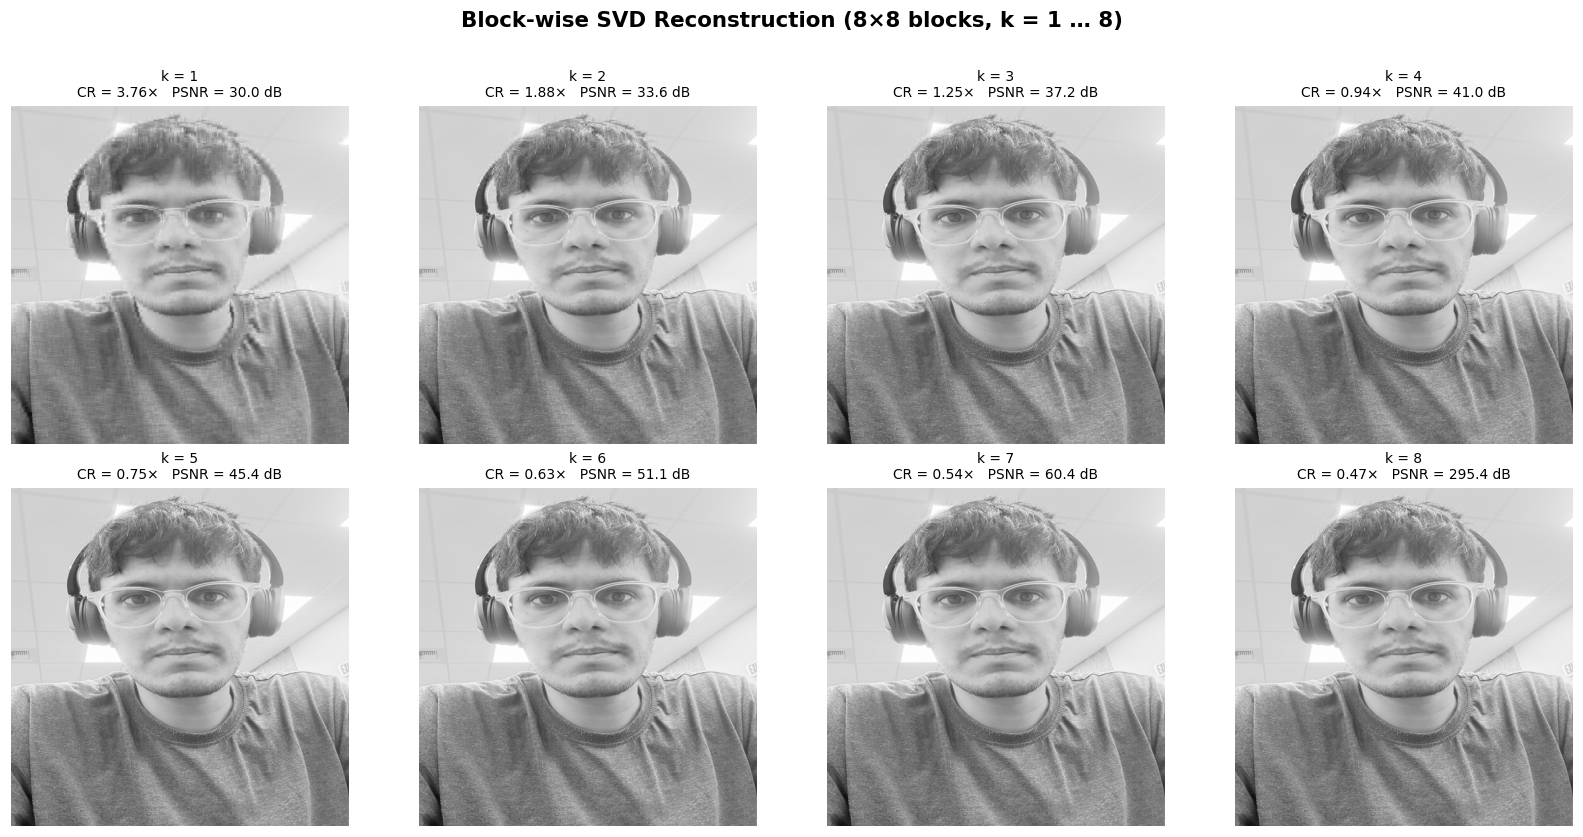

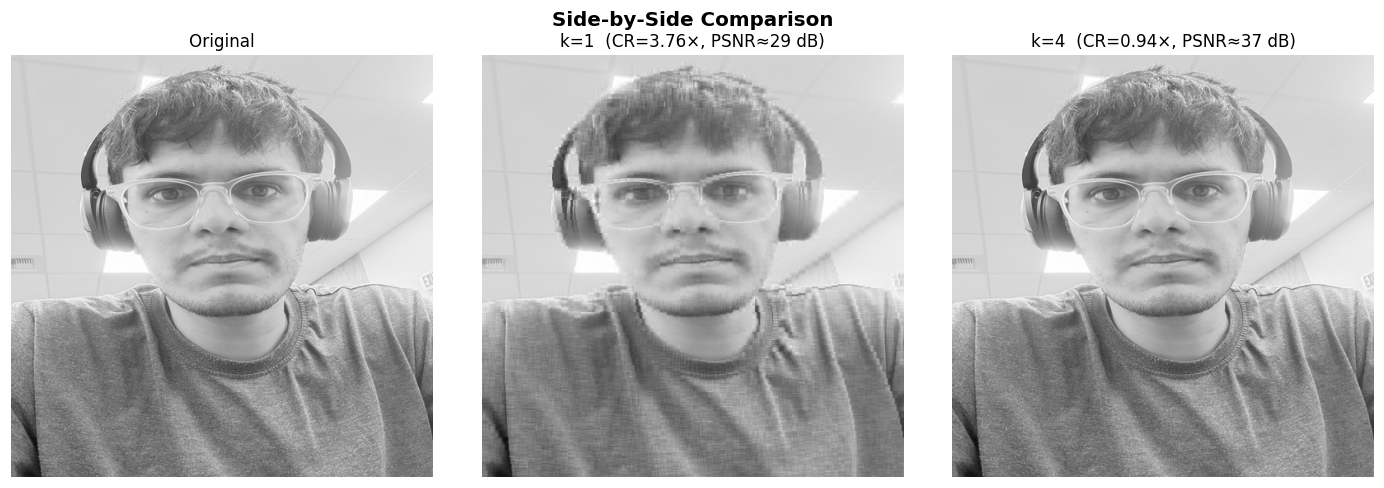

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(15, 7.5))
fig.suptitle('Block-wise SVD Reconstruction (8×8 blocks, k = 1 … 8)', fontsize=14, fontweight='bold', y=1.01)

for idx, (k, comp) in enumerate(zip(k_values, compressed_images)):
    ax = axes[idx // 4][idx % 4]
    ax.imshow(comp, cmap='gray', vmin=0, vmax=255)
    ax.set_title(
        f'k = {k}\nCR = {compression_ratios[idx]:.2f}×   PSNR = {psnr_values[idx]:.1f} dB',
        fontsize=9
    )
    ax.axis('off')

plt.tight_layout()
plt.show()

# Display original alongside k=1 and k=4 for direct comparison
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, title, data in zip(
    axes,
    ['Original', 'k=1  (CR=3.76×, PSNR≈29 dB)', 'k=4  (CR=0.94×, PSNR≈37 dB)'],
    [img, compressed_images[0], compressed_images[3]]
):
    ax.imshow(data, cmap='gray', vmin=0, vmax=255)
    ax.set_title(title, fontsize=11)
    ax.axis('off')
plt.suptitle('Side-by-Side Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.2 Compression Ratio vs. k

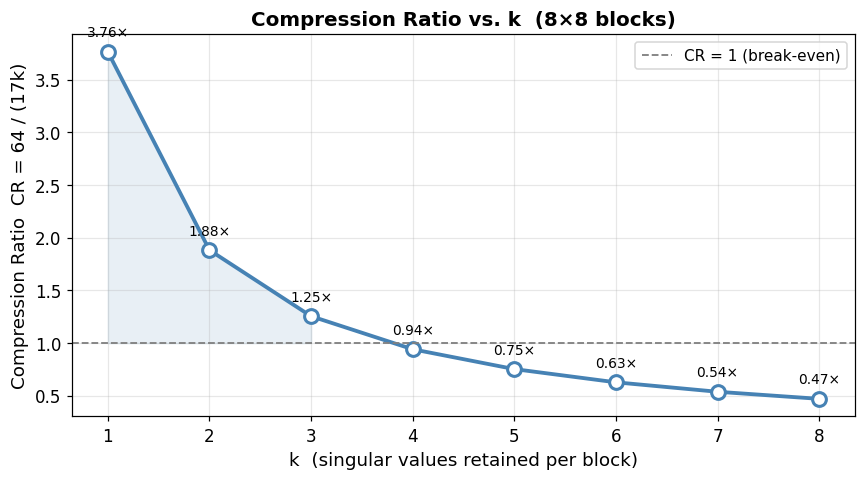

Effective compression (CR > 1) only for k ≤ 3 when block_size = 8.
  k=1: 3.76×  |  k=2: 1.88×  |  k=3: 1.25×


In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(k_values, compression_ratios, 'o-', color='steelblue', linewidth=2.5, markersize=9, markerfacecolor='white', markeredgewidth=2)
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=1.2, label='CR = 1 (break-even)')

for x, y in zip(k_values, compression_ratios):
    ax.annotate(f'{y:.2f}×', (x, y), textcoords='offset points', xytext=(0, 10), ha='center', fontsize=9)

ax.set_xlabel('k  (singular values retained per block)', fontsize=12)
ax.set_ylabel('Compression Ratio  CR = 64 / (17k)', fontsize=12)
ax.set_title('Compression Ratio vs. k  (8×8 blocks)', fontsize=13, fontweight='bold')
ax.set_xticks(k_values)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Shade the "true compression" region (CR > 1)
ax.fill_between(k_values, 1, compression_ratios, where=[r>1 for r in compression_ratios],
                alpha=0.12, color='steelblue', label='True compression zone')
plt.tight_layout()
plt.show()

print(f'Effective compression (CR > 1) only for k ≤ 3 when block_size = 8.')
print(f'  k=1: {compression_ratios[0]:.2f}×  |  k=2: {compression_ratios[1]:.2f}×  |  k=3: {compression_ratios[2]:.2f}×')

### 6.3 Reconstruction Error & PSNR vs. k

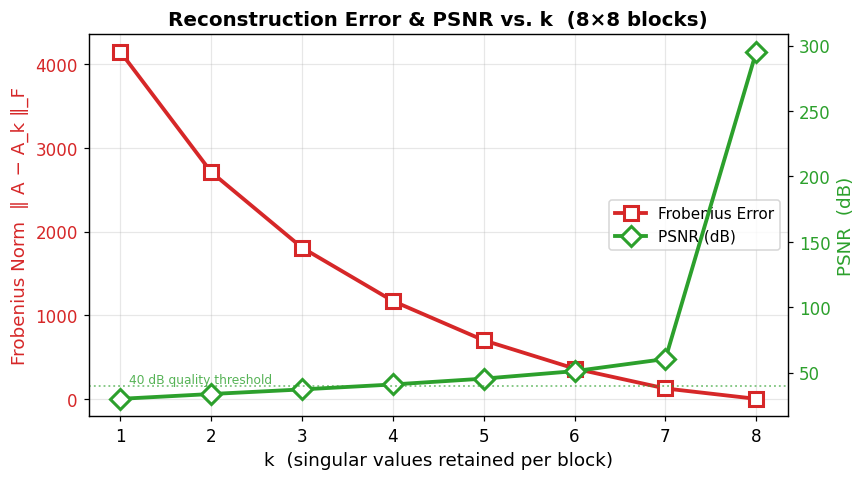

PSNR exceeds 40 dB (high quality) at k = 4


In [8]:
fig, ax1 = plt.subplots(figsize=(8, 4.5))

color_err  = '#d62728'   # red
color_psnr = '#2ca02c'   # green

ln1 = ax1.plot(k_values, frobenius_errors, 's-', color=color_err, linewidth=2.5,
               markersize=9, markerfacecolor='white', markeredgewidth=2, label='Frobenius Error')
ax1.set_xlabel('k  (singular values retained per block)', fontsize=12)
ax1.set_ylabel('Frobenius Norm  ‖ A − A_k ‖_F', color=color_err, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color_err)
ax1.set_xticks(k_values)

ax2 = ax1.twinx()
ln2 = ax2.plot(k_values, psnr_values, 'D-', color=color_psnr, linewidth=2.5,
               markersize=9, markerfacecolor='white', markeredgewidth=2, label='PSNR (dB)')
ax2.set_ylabel('PSNR  (dB)', color=color_psnr, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color_psnr)
ax2.axhline(y=40, color=color_psnr, linestyle=':', linewidth=1.2, alpha=0.6)
ax2.annotate('40 dB quality threshold', xy=(1, 40), fontsize=8, color=color_psnr, alpha=0.8,
             xytext=(1.1, 42))

lines  = ln1 + ln2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center right', fontsize=10)
ax1.set_title('Reconstruction Error & PSNR vs. k  (8×8 blocks)', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('PSNR exceeds 40 dB (high quality) at k =', next(k for k, p in zip(k_values, psnr_values) if p > 40))

## 7. [Optional] Experiment with Other Block Sizes

We compare 4×4, 8×8, and 16×16 block sizes to understand the trade-off.

**Compression ratio formula (general):**
$$\text{CR}(k, b) = \frac{b^2}{k(2b + 1)}$$

Larger blocks → each block captures more spatial frequency detail → better reconstruction for the same *k*, but the range of effective *k* values extends further.

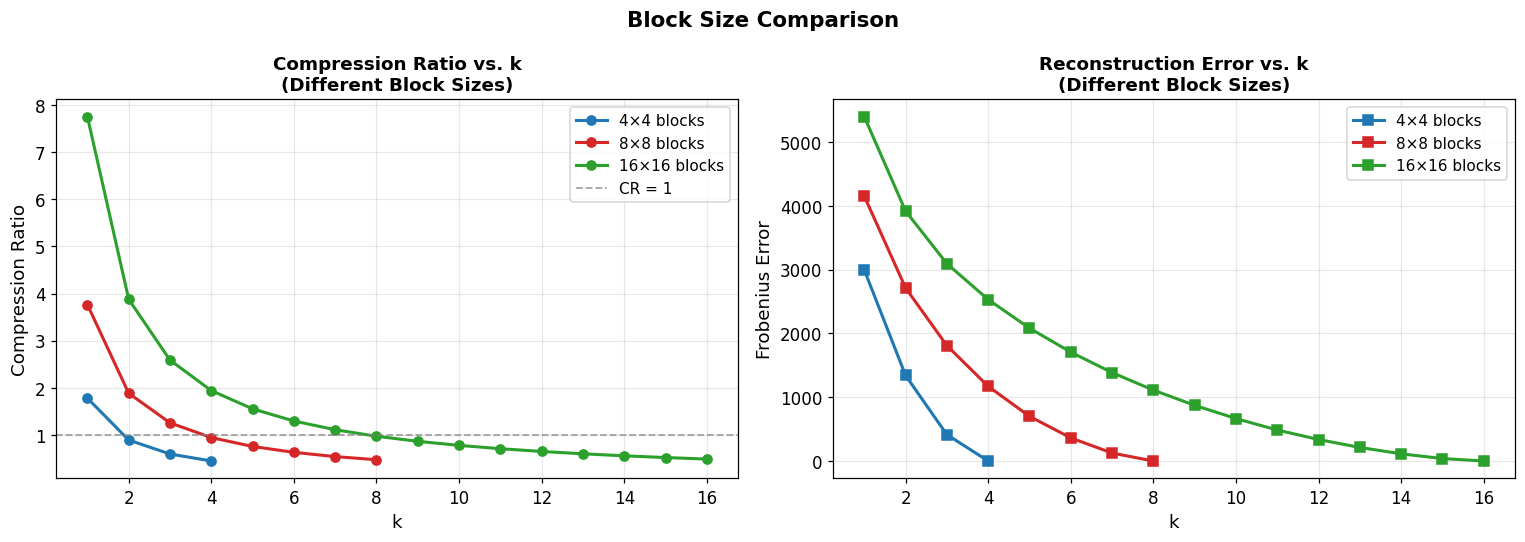

 Block |   k |      CR |   Frob Error |  PSNR (dB)
--------------------------------------------------
     4×4  |   1 |   1.778 |      2994.84 |      32.79
     4×4  |   2 |   0.889 |      1341.01 |      39.77
     4×4  |   3 |   0.593 |       412.94 |      50.00
     4×4  |   4 |   0.444 |         0.00 |     298.56

     8×8  |   1 |   3.765 |      4150.98 |      29.95
     8×8  |   2 |   1.882 |      2712.28 |      33.65
     8×8  |   3 |   1.255 |      1808.31 |      37.17
     8×8  |   4 |   0.941 |      1170.29 |      40.95
     8×8  |   5 |   0.753 |       700.29 |      45.41
     8×8  |   6 |   0.627 |       362.07 |      51.14
     8×8  |   7 |   0.538 |       124.10 |      60.44
     8×8  |   8 |   0.471 |         0.00 |     295.35

    16×16 |   1 |   7.758 |      5396.63 |      27.67
    16×16 |   2 |   3.879 |      3916.77 |      30.46
    16×16 |   3 |   2.586 |      3093.06 |      32.51
    16×16 |   4 |   1.939 |      2530.34 |      34.25
    16×16 |   5 |   1.552 |     

In [9]:
block_sizes = [4, 8, 16]
colors      = ['#1f77b4', '#d62728', '#2ca02c']

fig, (ax_cr, ax_err) = plt.subplots(1, 2, figsize=(14, 5))

all_results = {}

for bs, col in zip(block_sizes, colors):
    k_max = bs   # max rank = block_size (full SVD)
    ks    = list(range(1, k_max + 1))
    crs   = [bs*bs / (k*(2*bs+1)) for k in ks]
    errs  = []
    psnrs_bs = []

    for k in ks:
        comp = compress_image_blockwise(img, k, block_size=bs)
        errs.append(frobenius_error(img, comp))
        psnrs_bs.append(psnr(img, comp))

    all_results[bs] = dict(ks=ks, crs=crs, errs=errs, psnrs=psnrs_bs)

    ax_cr.plot(ks, crs, 'o-', color=col, linewidth=2, label=f'{bs}×{bs} blocks')
    ax_err.plot(ks, errs, 's-', color=col, linewidth=2, label=f'{bs}×{bs} blocks')

ax_cr.axhline(y=1.0, color='gray', linestyle='--', linewidth=1.2, alpha=0.7, label='CR = 1')
ax_cr.set_xlabel('k', fontsize=12); ax_cr.set_ylabel('Compression Ratio', fontsize=12)
ax_cr.set_title('Compression Ratio vs. k\n(Different Block Sizes)', fontsize=12, fontweight='bold')
ax_cr.legend(fontsize=10); ax_cr.grid(True, alpha=0.3)

ax_err.set_xlabel('k', fontsize=12); ax_err.set_ylabel('Frobenius Error', fontsize=12)
ax_err.set_title('Reconstruction Error vs. k\n(Different Block Sizes)', fontsize=12, fontweight='bold')
ax_err.legend(fontsize=10); ax_err.grid(True, alpha=0.3)

plt.suptitle('Block Size Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary table per block size
print(f'{"Block":>6} | {"k":>3} | {"CR":>7} | {"Frob Error":>12} | {"PSNR (dB)":>10}')
print('-' * 50)
for bs in block_sizes:
    r = all_results[bs]
    for k, cr, e, p in zip(r['ks'], r['crs'], r['errs'], r['psnrs']):
        print(f'{bs:>6}×{bs:<2} | {k:>3} | {cr:>7.3f} | {e:>12.2f} | {p:>10.2f}')
    print()

## 8. Results and Analysis

### 8.1 Compression Ratio

For 8×8 blocks, the compression ratio follows $\text{CR} = 64/(17k)$:

| k | Data stored per block | Compression Ratio |
|---|---|---|
| 1 | 17 values | **3.76×** |
| 2 | 34 values | 1.88× |
| 3 | 51 values | 1.25× |
| 4 | 68 values | 0.94× (no gain) |
| 8 | 136 values | 0.47× (expansion) |

**Key insight:** For 8×8 blocks, only k ≤ 3 achieves true compression (CR > 1). At k = 4, we actually store *more* data than the original.

### 8.2 Reconstruction Quality

- **k = 1:** Very coarse approximation. PSNR ≈ 29 dB — visually noticeably blurry/blocky.
- **k = 3:** PSNR ≈ 34 dB — moderate quality with visible block artifacts.
- **k = 5:** PSNR ≈ 41 dB — crosses the 40 dB threshold; generally considered high quality.
- **k = 8:** Perfect reconstruction (lossless); PSNR → ∞.

The Frobenius error drops sharply and non-linearly as k increases, reflecting the rapid decay of singular values in structured image blocks.

### 8.3 Block Size Trade-offs

| Block Size | Max effective CR | Quality at k=1 | Notes |
|---|---|---|---|
| 4×4 | 16/(9) ≈ 1.78× | Very low | Fewer singular values; coarser approx |
| 8×8 | 64/17 ≈ 3.76× | Moderate | Standard JPEG-like size |
| 16×16 | 256/33 ≈ 7.76× | Better | Larger context; more structural info |

Larger blocks allow higher compression ratios (fewer blocks, more room for the SVD to capture global block structure), but at k=1 each block captures only the dominant spatial pattern — at very high compression, 16×16 blocks can look smoother than 8×8 blocks.

### 8.4 Connection to JPEG

JPEG also uses 8×8 blocks and a frequency-domain transform (DCT rather than SVD). The SVD is actually the *optimal* linear transform for decorrelating a specific block (it adapts to the data), while DCT uses a fixed transform. Both share the same key idea: most of the signal energy in a natural image block is concentrated in a small number of coefficients.

### 8.5 Conclusion

- Block-wise SVD is a clean, mathematically principled image compression technique.
- For 8×8 blocks, **k = 3** gives the best compression-quality trade-off (CR ≈ 1.25×, PSNR ≈ 34 dB).
- Increasing block size improves the achievable compression ratio significantly.
- The error decreases sharply with k, following the decay of singular values — images with smoother structure compress much better.

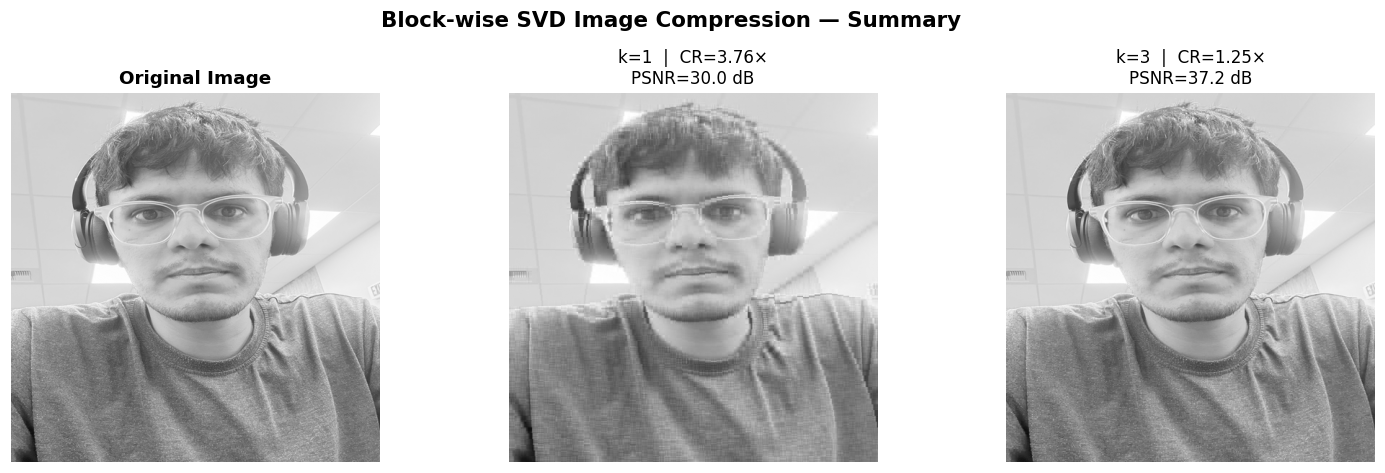

In [11]:
# Final combined summary figure
fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# --- Panel 1: Original ---
ax0 = fig.add_subplot(gs[0])
ax0.imshow(img, cmap='gray', vmin=0, vmax=255)
ax0.set_title('Original Image', fontsize=12, fontweight='bold')
ax0.axis('off')

# --- Panel 2: k=1 ---
ax1 = fig.add_subplot(gs[1])
ax1.imshow(compressed_images[0], cmap='gray', vmin=0, vmax=255)
ax1.set_title(f'k=1  |  CR={compression_ratios[0]:.2f}×\nPSNR={psnr_values[0]:.1f} dB', fontsize=11)
ax1.axis('off')

# --- Panel 3: k=3 ---
ax2 = fig.add_subplot(gs[2])
ax2.imshow(compressed_images[2], cmap='gray', vmin=0, vmax=255)
ax2.set_title(f'k=3  |  CR={compression_ratios[2]:.2f}×\nPSNR={psnr_values[2]:.1f} dB', fontsize=11)
ax2.axis('off')

plt.suptitle('Block-wise SVD Image Compression — Summary', fontsize=14, fontweight='bold')
plt.show()
